In [1]:
import pandas as pd
import numpy as np
import torch
import cv2
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.optim import Adam
from tqdm import tqdm
import matplotlib.pyplot as plt
# Load CSVs
df_coords = pd.read_csv("original_1600_grid_points.csv")
df_valid = pd.read_csv("inside.csv", header=None, names=['X','Y'])
df_measurements = pd.read_csv("combined_sinr.csv")  # 30 × 7700
print(df_measurements.shape)


img = plt.imread("map_of_R1_Hall.png")
img_h, img_w = img.shape[0], img.shape[1]
print("Map size:", img_w, "x", img_h)

H, W = 40, 40

# Coordinates → Grid Indices
# Previous mapping func
def coords_to_indices(df, H, W):
    x_vals = df['X'].values
    y_vals = df['Y'].values

    x_norm = (x_vals - x_vals.min()) / (x_vals.max() - x_vals.min())
    y_norm = (y_vals - y_vals.min()) / (y_vals.max() - y_vals.min())

    x_idx = np.clip((x_norm * (W-1)).astype(int), 0, W-1)
    y_idx = np.clip((y_norm * (H-1)).astype(int), 0, H-1)

    return np.stack([y_idx, x_idx], axis=1)

# New mapping func
def coords_to_grid_binning(df, H=40, W=40, img_h=None, img_w=None):

    xs = df["X"].values.astype(float)
    ys = df["Y"].values.astype(float)

    x_idx = (xs / img_w * W).astype(int)
    y_idx = (ys / img_h * H).astype(int)

    x_idx = np.clip(x_idx, 0, W-1)
    y_idx = np.clip(y_idx, 0, H-1)

    return y_idx, x_idx


# Valid region mask
# valid_indices = coords_to_indices(df_valid, H, W)
# df_valid → grid index. valid_y and valid_x are lists of index
valid_y, valid_x = coords_to_grid_binning(df_valid, H, W, img_h, img_w)
# print(type(valid_y), valid_y)
# print(type(valid_y), valid_y)

valid_mask = torch.zeros((H, W), dtype=torch.bool)
for y, x in zip(valid_y, valid_x):
    valid_mask[y, x] = 1


# For a point, if its 8 neighbors are all inside points, then the point is considered as an inside point
def fill_holes_8_neighbors(mask):

    H, W = mask.shape
    new_mask = mask.copy()

    for y in range(1, H - 1):
        for x in range(1, W - 1):
            if mask[y, x] == 0:

                region = mask[y-1:y+2, x-1:x+2]

                if np.sum(region) == 8:
                    new_mask[y, x] = 1

    return new_mask


(30, 7751)
Map size: 1086 x 1105


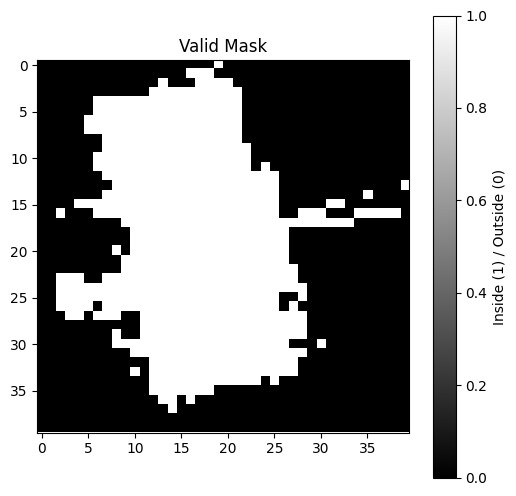

In [2]:
valid_indices = fill_holes_8_neighbors(valid_mask.cpu().numpy())
# Show valid mask
plt.figure(figsize=(6,6))
plt.imshow(valid_indices, cmap='gray', origin='upper')
plt.title("Valid Mask")
plt.colorbar(label="Inside (1) / Outside (0)")
# plt.savefig("xgboost/valid_mask.png", dpi=300, bbox_inches='tight')
plt.show()

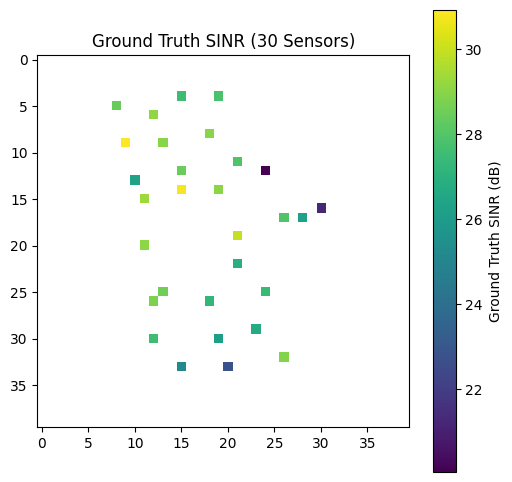

In [5]:
sinr_y, sinr_x = coords_to_grid_binning(df_measurements[['X','Y']], H, W, img_h, img_w)
measurement_indices = np.stack([sinr_y, sinr_x], axis=1)

# print(measurement_indices.shape)
# print(measurement_indices[:10])

# Create Valid Mask
valid_mask = torch.zeros((H, W), dtype=torch.bool)
valid_mask[valid_indices[:,0], valid_indices[:,1]] = True
valid_coords_mask = valid_mask.unsqueeze(0).unsqueeze(0).float()  # (1,1,H,W)
mask_2d = valid_coords_mask[0, 0].cpu().numpy()  # shape → (40,40), 0: outside; 1: inside

# Extract SINR samples (30 × 7749)
data_array = df_measurements.iloc[:, 2:].values.astype(np.float32) # (30, 7749)
num_sensors, num_samples = data_array.shape
sensor_mean_raw = data_array.mean(axis=1)   # shape (30,)

ys = measurement_indices[:, 0]
xs = measurement_indices[:, 1]

X_train = np.vstack([xs, ys]).T   # (x, y) x 30
Y_train = sensor_mean_raw         # (sinr) x 30

inside_map_real = np.full((H, W), np.nan, dtype=np.float32)
for i in range(len(ys)):
    y = ys[i]
    x = xs[i]
    inside_map_real[y, x] = sensor_mean_raw[i]

plt.figure(figsize=(6,6))
plt.imshow(inside_map_real, cmap='viridis', origin='upper')
plt.colorbar(label="Ground Truth SINR (dB)")
plt.title("Ground Truth SINR (30 Sensors)")
# plt.savefig("xgboost/gt.png", dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# Model training (30 points)
import xgboost as xgb

model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.02,
    max_depth=5,
    subsample=1.0,
    colsample_bytree=1.0,
)

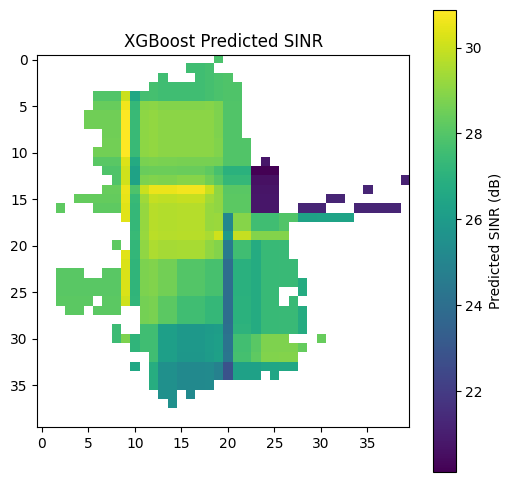

In [37]:
from scipy.ndimage import gaussian_filter

model.fit(X_train, Y_train)
grid_xy = np.array([(x,y) for y in range(H) for x in range(W)])
sinr_pred = model.predict(grid_xy)
sinr_map = sinr_pred.reshape(H, W)

# for (x, y), pred in zip(grid_xy, sinr_pred):
#     print(f"({x}, {y}) → {pred:.3f} dB")


inside_map = np.full((H, W), np.nan, dtype=np.float32)
ys, xs = np.where(valid_indices == True)  # Inside points

for y, x in zip(ys, xs):
    inside_map[y, x] = sinr_map[y, x]

plt.figure(figsize=(6,6))
plt.imshow(inside_map, cmap='viridis', origin='upper')
plt.colorbar(label="Predicted SINR (dB)")
plt.title("XGBoost Predicted SINR")
# plt.savefig("xgboost/XGBoost_SINR.png", dpi=300, bbox_inches='tight')
plt.show()
# temp_map = np.copy(inside_map)
# nan_mask = np.isnan(temp_map)

# mean_val = np.nanmean(temp_map)
# temp_map[nan_mask] = mean_val

# # Gaussian smoothing
# smoothed = gaussian_filter(temp_map, sigma=1.2)
# smoothed[nan_mask] = np.nan
# plt.figure(figsize=(6,6))
# plt.imshow(smoothed, cmap='viridis', origin='upper')
# plt.colorbar(label="Smoothed SINR (dB)")
# plt.title("Smoothed XGBoost Predicted SINR (30 points)")
# plt.show()

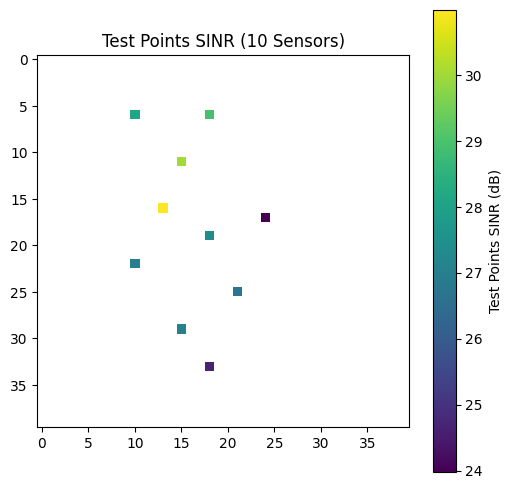

Point 1: (x=13, y=16)
  Predicted: 29.618 dB
  GroundTruth: 30.988 dB
  Error: -1.370 dB

Point 2: (x=24, y=17)
  Predicted: 27.559 dB
  GroundTruth: 23.983 dB
  Error: 3.576 dB

Point 3: (x=18, y=19)
  Predicted: 29.510 dB
  GroundTruth: 27.350 dB
  Error: 2.160 dB

Point 4: (x=21, y=25)
  Predicted: 26.965 dB
  GroundTruth: 26.728 dB
  Error: 0.237 dB

Point 5: (x=15, y=29)
  Predicted: 25.835 dB
  GroundTruth: 27.060 dB
  Error: -1.225 dB

Point 6: (x=18, y=33)
  Predicted: 25.257 dB
  GroundTruth: 24.649 dB
  Error: 0.608 dB

Point 7: (x=10, y=22)
  Predicted: 27.136 dB
  GroundTruth: 26.990 dB
  Error: 0.145 dB

Point 8: (x=10, y=6)
  Predicted: 27.398 dB
  GroundTruth: 28.105 dB
  Error: -0.706 dB

Point 9: (x=18, y=6)
  Predicted: 29.004 dB
  GroundTruth: 28.955 dB
  Error: 0.049 dB

Point 10: (x=15, y=11)
  Predicted: 28.684 dB
  GroundTruth: 30.011 dB
  Error: -1.327 dB



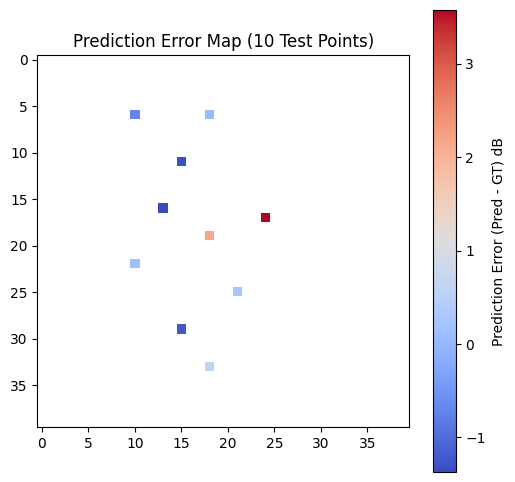

Saved: xgboost/test_error.png


In [11]:
# Calculate MSE and validate
test_sinr = pd.read_csv("combined_test_sinr.csv")  # 10 × 4200
sinr_yt, sinr_xt = coords_to_grid_binning(test_sinr[['X','Y']], H, W, img_h, img_w)
test_indices = np.stack([sinr_yt, sinr_xt], axis=1)
test_array = test_sinr.iloc[:, 2:].values.astype(np.float32) # (10, 4200)
num_sensors_t, num_samples_t = test_array.shape
sensor_mean_raw_t = test_array.mean(axis=1)   # shape (10,)

yst = test_indices[:, 0]
xst = test_indices[:, 1]

X_test = np.vstack([xst, yst]).T   # (x, y)
Y_test = sensor_mean_raw_t         # (sinr)
inside_map_realt = np.full((H, W), np.nan, dtype=np.float32)
for i in range(len(yst)):
    y = yst[i]
    x = xst[i]
    inside_map_realt[y, x] = sensor_mean_raw_t[i]

plt.figure(figsize=(6,6))
plt.imshow(inside_map_realt, cmap='viridis', origin='upper')
plt.colorbar(label="Test Points SINR (dB)")
plt.title("Test Points SINR (10 Sensors)")
# plt.savefig("xgboost/test.png", dpi=300, bbox_inches='tight')
plt.show()

errors = []

for i in range(len(yst)):
    x = xst[i]
    y = yst[i]
    pred = sinr_map[y, x]
    gt   = sensor_mean_raw_t[i]
    err  = pred - gt
    errors.append(err)
    print(f"Point {i + 1}: (x={x}, y={y})")
    print(f"  Predicted: {pred:.3f} dB")
    print(f"  GroundTruth: {gt:.3f} dB")
    print(f"  Error: {pred - gt:.3f} dB\n")

errors = np.array(errors)   # shape (10,)

error_map = np.full((H, W), np.nan, dtype=np.float32)

# Fill only test points with their error
for i in range(len(yst)):
    error_map[yst[i], xst[i]] = errors[i]


plt.figure(figsize=(6,6))
plt.imshow(error_map, cmap="coolwarm", origin='upper')
plt.colorbar(label="Prediction Error (Pred - GT) dB")
plt.title("Prediction Error Map (10 Test Points)")
# plt.savefig("xgboost/test_error.png", dpi=300, bbox_inches='tight')
plt.show()

print("Saved: xgboost/test_error.png")

In [33]:
# Model training (10 points)
import xgboost as xgb

model_10 = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.001,
    max_depth=5,
    subsample=1.0,
    colsample_bytree=1.0,
)

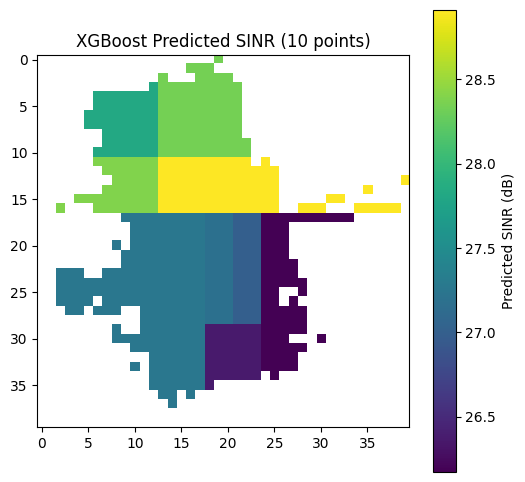

In [35]:
model_10.fit(X_test, Y_test)
grid_xy = np.array([(x,y) for y in range(H) for x in range(W)])
sinr_pred = model_10.predict(grid_xy)
sinr_map = sinr_pred.reshape(H, W)

# for (x, y), pred in zip(grid_xy, sinr_pred):
#     print(f"({x}, {y}) → {pred:.3f} dB")


inside_map = np.full((H, W), np.nan, dtype=np.float32)
ys, xs = np.where(valid_indices == True)  # Inside points

for y, x in zip(ys, xs):
    inside_map[y, x] = sinr_map[y, x]

plt.figure(figsize=(6,6))
plt.imshow(inside_map, cmap='viridis', origin='upper')
plt.colorbar(label="Predicted SINR (dB)")
plt.title("XGBoost Predicted SINR (10 points)")
# plt.savefig("xgboost/XGBoost_SINR.png", dpi=300, bbox_inches='tight')
plt.show()
# temp_map = np.copy(inside_map)
# nan_mask = np.isnan(temp_map)

# mean_val = np.nanmean(temp_map)
# temp_map[nan_mask] = mean_val

# # Gaussian smoothing
# smoothed = gaussian_filter(temp_map, sigma=1.2)
# smoothed[nan_mask] = np.nan
# plt.figure(figsize=(6,6))
# plt.imshow(smoothed, cmap='viridis', origin='upper')
# plt.colorbar(label="Smoothed SINR (dB)")
# plt.title("Smoothed XGBoost Predicted SINR(10 points)")
# plt.show()